## Импорты и утилиты

In [48]:
import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
import statsmodels.api as sm

import matplotlib.pyplot as plt

np.random.seed(42)
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

In [95]:
data = pd.read_csv('D:/ML finance/MLP/data_t.csv', index_col='openTime')

In [96]:
data.index = pd.to_datetime(data.index)

In [97]:
ret_columns = []

for col in data.columns:
    if 'ret' in col:
        ret_columns.append(col)

In [98]:
ret = data[ret_columns]
mkt_s = ret.mean(axis=1)

### Optimization

In [99]:
close_columns = []

for col in data.columns:
    if 'close' in col:
        close_columns.append(col)

### Веса

<Axes: xlabel='openTime'>

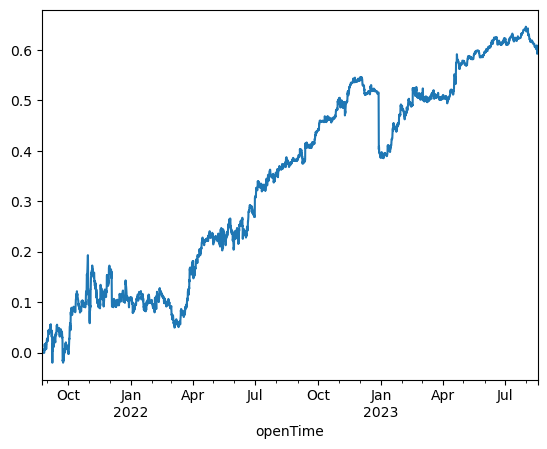

In [142]:
alpha_signal = 1/(data[close_columns] / data[close_columns].shift(10) - 1)
vol = data[close_columns].rolling(20).std()
alpha_signal = alpha_signal / vol.replace(0, np.nan)

alpha_signal = alpha_signal.sub(alpha_signal.mean(axis=1), axis=0)
w = alpha_signal.div(alpha_signal.abs().sum(axis=1), axis=0)
(w * ret.values).sum(axis=1).cumsum().plot()

### Метрики

In [150]:
pnl = (w * ret.values).sum(axis=1)

pnl_sum = pnl.sum()
vol = pnl.std()
sharpe = (pnl.mean() / vol) * np.sqrt(365 * 6)
max_dd = (
    (
        pnl.cumsum().cummax() -
        pnl.cumsum()
    ) / 
    (1 + pnl.cumsum().cummax())
).max()
tvr = (w.diff().abs()).sum(axis=1).resample('1D').sum().mean()
pm = pnl_sum / tvr

res = {
    'pnl_sum': pnl_sum,
    'volatility': vol,
    'sharpe': sharpe,
    'max_dd': max_dd,
    'tvr': tvr,
    'profit_margin': pm
}

res = pd.DataFrame(res, index=['no_beta_neutralize'])
res

,pnl_sum,volatility,sharpe,max_dd,tvr,profit_margin
no_beta_neutralize,0.597823,0.004295,1.499906,0.120152,3.090315,0.193451


### PCA

In [175]:
window = 42
n_components = 1  

factor_loadings = [] 
pca_weights_history = [] 

for t in range(window, len(ret)):
    hist_ret = ret.iloc[t-window:t]
    hist_ret_std = (hist_ret - hist_ret.mean()) / hist_ret.std()
    pca = PCA(n_components=n_components)
    pca.fit(hist_ret_std)
    loadings = pca.components_  
    factor_loadings.append(loadings)
    w_alpha = w.iloc[t].values
    if t % 100 == 0:
        print(f"Обработано {t} из {len(ret)}")

Обработано 100 из 4343
Обработано 200 из 4343
Обработано 300 из 4343
Обработано 400 из 4343
Обработано 500 из 4343
Обработано 600 из 4343
Обработано 700 из 4343
Обработано 800 из 4343
Обработано 900 из 4343
Обработано 1000 из 4343
Обработано 1100 из 4343
Обработано 1200 из 4343
Обработано 1300 из 4343
Обработано 1400 из 4343
Обработано 1500 из 4343
Обработано 1600 из 4343
Обработано 1700 из 4343
Обработано 1800 из 4343
Обработано 1900 из 4343
Обработано 2000 из 4343
Обработано 2100 из 4343
Обработано 2200 из 4343
Обработано 2300 из 4343
Обработано 2400 из 4343
Обработано 2500 из 4343
Обработано 2600 из 4343
Обработано 2700 из 4343
Обработано 2800 из 4343
Обработано 2900 из 4343
Обработано 3000 из 4343
Обработано 3100 из 4343
Обработано 3200 из 4343
Обработано 3300 из 4343
Обработано 3400 из 4343
Обработано 3500 из 4343
Обработано 3600 из 4343
Обработано 3700 из 4343
Обработано 3800 из 4343
Обработано 3900 из 4343
Обработано 4000 из 4343
Обработано 4100 из 4343
Обработано 4200 из 4343
О

### Новые веса; Оптимизация

In [176]:
beta_neutral_weights = []

for t in range(window, len(ret)):
    w_alpha = w.iloc[t].values
    loadings = factor_loadings[t - window]
    
    A = np.ones((1, len(w_alpha)))
    A = np.vstack([A, loadings])
    b = np.zeros(A.shape[0])
    
    try:
        At = A.T
        AAt = A @ At
        AAt_inv = np.linalg.inv(AAt + 1e-8 * np.eye(AAt.shape[0]))
        x = w_alpha - At @ AAt_inv @ (A @ w_alpha)
        
    except np.linalg.LinAlgError:
        x = w_alpha - At @ np.linalg.pinv(AAt) @ (A @ w_alpha)
    
    beta_neutral_weights.append(x)

beta_neutral_weights = pd.DataFrame(beta_neutral_weights, 
                                     index=ret.index[window:],
                                     columns=ret.columns)

      Strategy  Total Return  Volatility   Sharpe    Max DD  Turnover  Profit Margin
Original Alpha      0.581204    0.004304 1.469463 -0.121849  3.090315       0.188073
   PCA Neutral      0.662389    0.004605 1.565086 -0.090970  3.283161       0.201753


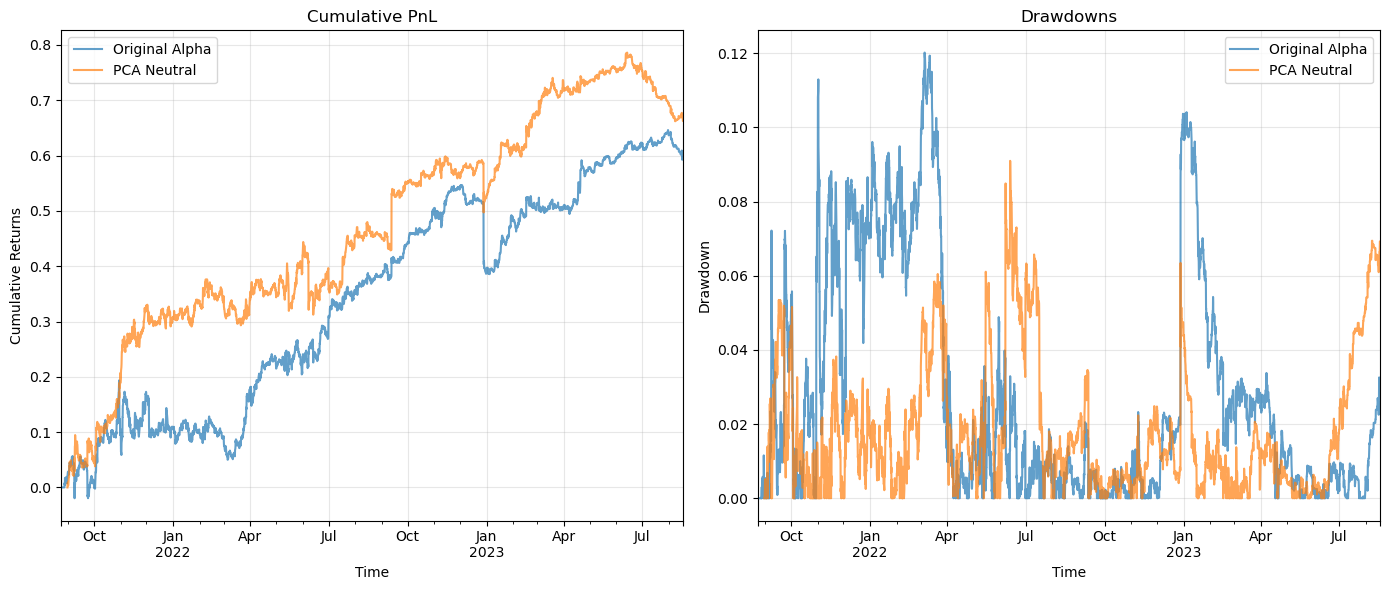

In [177]:
pnl_pca = (beta_neutral_weights.shift(1) * ret.loc[beta_neutral_weights.index]).sum(axis=1)

def calculate_metrics(pnl, weights, name="Strategy"):
    """Расчет метрик для стратегии"""
    pnl = pnl.dropna()

    total_return = pnl.sum()
    volatility = pnl.std()
    sharpe = (pnl.mean() / volatility) * np.sqrt(365*6)

    cumulative = pnl.cumsum()
    running_max = cumulative.expanding().max()
    drawdown = (cumulative - running_max) / (1 + running_max)
    max_dd = drawdown.min()
    tvr = weights.diff().abs().sum(axis=1).resample('1D').sum().mean()
    profit_margin = total_return / tvr if tvr != 0 else 0
    
    return {
        'Strategy': name,
        'Total Return': total_return,
        'Volatility': volatility,
        'Sharpe': sharpe,
        'Max DD': max_dd,
        'Turnover': tvr,
        'Profit Margin': profit_margin
    }

metrics_original = calculate_metrics(
    (w * ret.values).sum(axis=1).loc[beta_neutral_weights.index], 
    w, 
    "Original Alpha"
)

metrics_pca = calculate_metrics(
    pnl_pca,
    beta_neutral_weights,
    "PCA Neutral"
)


metrics_df = pd.DataFrame([metrics_original, metrics_pca])
print(metrics_df.to_string(index=False))



plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
(w * ret.values).sum(axis=1).cumsum().plot(label='Original Alpha', alpha=0.7)
pnl_pca.cumsum().plot(label='PCA Neutral', alpha=0.7)
plt.title('Cumulative PnL')
plt.xlabel('Time')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
cum_orig = (w * ret.values).sum(axis=1).cumsum()
dd_orig = (cum_orig.cummax() - cum_orig) / (1 + cum_orig.cummax())
dd_orig.plot(label='Original Alpha', alpha=0.7)

cum_pca = pnl_pca.cumsum()
dd_pca = (cum_pca.cummax() - cum_pca) / (1 + cum_pca.cummax())
dd_pca.plot(label='PCA Neutral', alpha=0.7)

plt.title('Drawdowns')
plt.xlabel('Time')
plt.ylabel('Drawdown')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()